# AniMatch — Exploratory Data Analysis

This notebook explores the anime dataset before building the recommender in `recommender.py`.
Goal: understand the genre landscape, rating distribution, and data quality issues that shaped
the cleaning decisions in `prepare_data.py`.

**Dataset:** MyAnimeList data via the [tidytuesday project](https://github.com/rfordatascience/tidytuesday).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("data/anime_clean.csv")
df.shape


(5605, 12)

## 1. A first look at the data

In [2]:
df.head()


,animeID,name,type,genre,studio,episodes,score,scored_by,popularity,members,synopsis,combined_text
0,1,Cowboy Bebop,TV,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Sunrise,26.0,8.81,405664,39,795733,"In the year 2071, humanity has colonized sever...","Action, Adventure, Comedy, Drama, Sci-Fi, Spac..."
1,5,Cowboy Bebop: Tengoku no Tobira,Movie,"Action, Drama, Mystery, Sci-Fi, Space",Bones,1.0,8.41,120243,449,197791,"Another day, another bounty—such is the life o...","Action, Drama, Mystery, Sci-Fi, Space Action, ..."
2,6,Trigun,TV,"Action, Adventure, Comedy, Drama, Sci-Fi, Shounen",Madhouse,26.0,8.30,212537,146,408548,"Vash the Stampede is the man with a $$60,000,0...","Action, Adventure, Comedy, Drama, Sci-Fi, Shou..."
3,7,Witch Hunter Robin,TV,"Action, Drama, Magic, Mystery, Police, Superna...",Sunrise,26.0,7.33,32837,1171,79397,Witches are individuals with special powers li...,"Action, Drama, Magic, Mystery, Police, Superna..."
4,8,Bouken Ou Beet,TV,"Adventure, Fantasy, Shounen, Supernatural",Toei Animation,52.0,7.03,4894,3704,11708,It is the dark century and the people are suff...,"Adventure, Fantasy, Shounen, Supernatural Adve..."


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5605 entries, 0 to 5604
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   animeID        5605 non-null   int64  
 1   name           5605 non-null   str    
 2   type           5605 non-null   str    
 3   genre          5605 non-null   str    
 4   studio         5159 non-null   str    
 5   episodes       5580 non-null   float64
 6   score          5605 non-null   float64
 7   scored_by      5605 non-null   int64  
 8   popularity     5605 non-null   int64  
 9   members        5605 non-null   int64  
 10  synopsis       5605 non-null   str    
 11  combined_text  5605 non-null   str    
dtypes: float64(2), int64(4), str(6)
memory usage: 525.6 KB


## 2. Rating distribution

How are MAL scores distributed across anime? This matters for the recommender: if scores
cluster tightly, a fixed `min_score` filter (used in `recommender.py`) behaves very differently
than if scores are spread out.

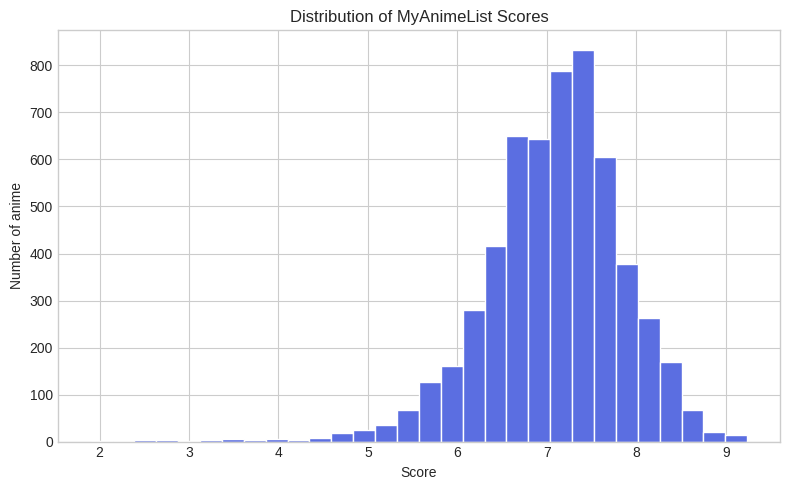

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
df["score"].dropna().hist(bins=30, ax=ax, color="#5b6ee1", edgecolor="white")
ax.set_title("Distribution of MyAnimeList Scores")
ax.set_xlabel("Score")
ax.set_ylabel("Number of anime")
plt.tight_layout()
plt.savefig("notebook_assets_score_dist.png", dpi=120)
plt.show()


**Observation:** scores are left-skewed and cluster between 6 and 8 — most anime that get
enough ratings to appear in this cleaned dataset are at least decently received. This is part of
why the cleaning step in `prepare_data.py` drops anime with fewer than 1,000 scorers: very
low-vote anime have noisy, unreliable scores.

## 3. Most common genres

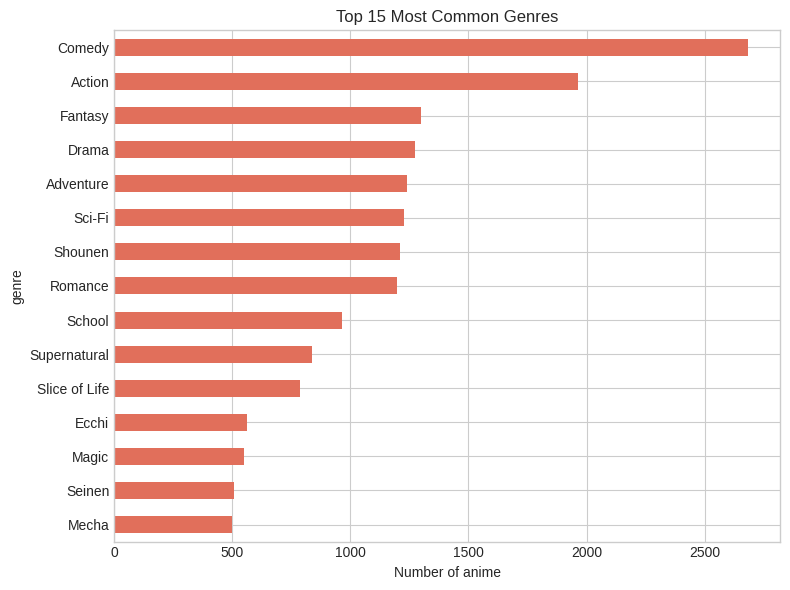

In [5]:
genre_counts = (
    df["genre"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
genre_counts.sort_values().plot(kind="barh", ax=ax, color="#e16f5b")
ax.set_title("Top 15 Most Common Genres")
ax.set_xlabel("Number of anime")
plt.tight_layout()
plt.savefig("notebook_assets_genre_counts.png", dpi=120)
plt.show()


**Observation:** Comedy, Action, and Drama dominate. This imbalance matters for a
TF-IDF-based recommender — without down-weighting common genres, "Comedy" would barely help
distinguish anime, since nearly everything has it. TF-IDF naturally handles this: genres that
appear less often (e.g. "Space", "Military") get a higher weight when they do appear, which is
exactly the property we want for finding *specific* similarity rather than generic similarity.

## 4. Score vs. popularity

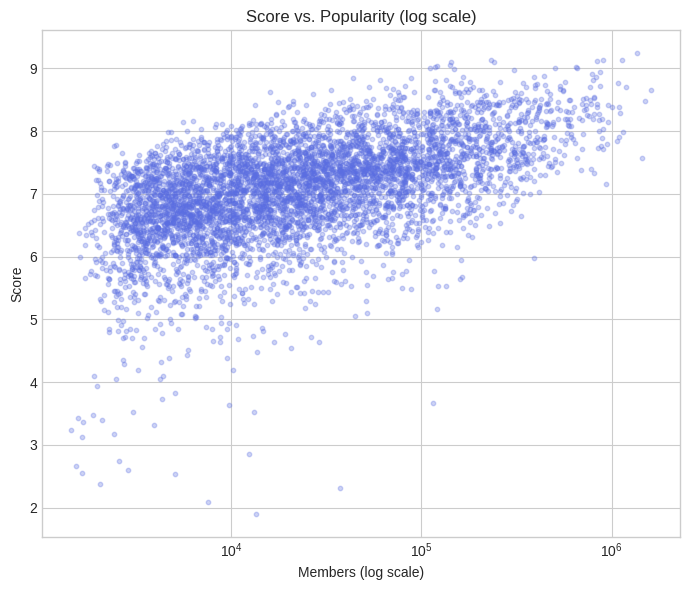

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["members"], df["score"], alpha=0.3, s=10, color="#5b6ee1")
ax.set_xscale("log")
ax.set_title("Score vs. Popularity (log scale)")
ax.set_xlabel("Members (log scale)")
ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig("notebook_assets_score_vs_popularity.png", dpi=120)
plt.show()


**Observation:** there's a mild positive trend — more popular anime tend to score slightly
higher on average, likely because popularity itself is partly driven by quality, and very obscure
shows have noisier scores from fewer raters. This supports filtering low-vote anime during cleaning.

## 5. Episode count distribution

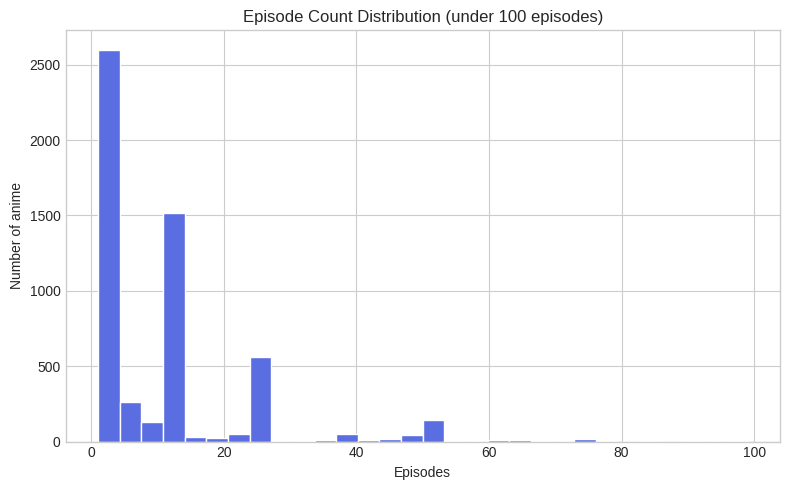

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
df[df["episodes"] < 100]["episodes"].dropna().hist(bins=30, ax=ax, color="#5b6ee1", edgecolor="white")
ax.set_title("Episode Count Distribution (under 100 episodes)")
ax.set_xlabel("Episodes")
ax.set_ylabel("Number of anime")
plt.tight_layout()
plt.savefig("notebook_assets_episode_dist.png", dpi=120)
plt.show()


**Observation:** most anime are short — under 26 episodes (one or two TV seasons). Long-runners
like *Bleach* (366 episodes) or *One Piece* are clear outliers, which is worth knowing since
episode count isn't currently used as a recommendation feature, but could be in a future
"similar commitment level" filter (see README).

## 6. Takeaways that shaped `prepare_data.py` and `recommender.py`

- **Score noise at low vote counts** → filtered anime with `scored_by < 1000`.
- **Genre imbalance** → used TF-IDF (not raw genre counts) so rare, more distinctive genres
  carry more weight in similarity calculations.
- **Genres should matter more than synopsis wording** → genre text is repeated 3x before
  vectorizing, so two anime sharing genres outweigh two anime that just share generic
  synopsis phrasing ("a group of friends...").
- **Duplicate/movie-spinoff entries** → deduplicated by title to avoid near-identical entries
  cluttering recommendations.

Next steps for this analysis are tracked in the main README under "Next Steps".
